# 3G - Ciclo de vida do Nino 3.4 em relacao ao DHW (NOAA/ONI local)

**Pergunta especifica.** Como o calor acumulado DHW se comporta nas classes NOAA (`fraco`, `moderado`, `forte`, `muito_forte`): antecede, acompanha ou ecoa a SSTA?

**Objetivo.** Posicionar o DHW no ciclo fisico e testar se ele mede severidade/duracao nas classes oficiais de intensidade.

**Justificativa.** O DHW nao define sozinho o evento; ele resume a carga termica acumulada dos eventos que cumprem a regra termica/temporal NOAA. A metrica canonica agora acumula somente HotSpots diarios de SSTA >=+0.5 C em janela movel de 12 semanas.

**Metodologia.** Composto SSTA x DHW alinhado ao pico por classe NOAA; DHW por fase; escalonamento DHW_max vs pico/duracao; validacao temporal por media movel de 12 semanas >=+0.5 C sustentada por 20 semanas. **Area:** caixa Nino 3.4.

**Saidas.** `phase3G_eventos_dhw.csv`, `phase3G_composto_ssta_dhw_classes_noaa.csv`, `phase3G_composto_ssta_dhw.csv`, `phase3G_pico_dhw_por_classe.csv`, `phase3G_escalonamento.csv`, `phase3G_estado_atual.csv` + figuras.


[tabela] data\processed\parquet\statistics\phase3G_composto_ssta_dhw_classes_noaa.csv
[tabela] data\processed\parquet\statistics\phase3G_composto_ssta_dhw.csv
[tabela] data\processed\parquet\statistics\phase3G_pico_dhw_por_classe.csv
Pico composto do DHW C-week >=0.5C por classe NOAA:
      grupo      rotulo  n_eventos  lag_pico_dhw_sem  dhw_pico_max_c_weeks
      fraco       Fraco          4                 7                 10.25
   moderado    Moderado          2                11                 14.99
      forte       Forte          3                 9                 20.69
muito_forte Muito forte          3                 8                 27.53


[figura] data\processed\figures\fase3\phase3G_composto_ssta_dhw.png


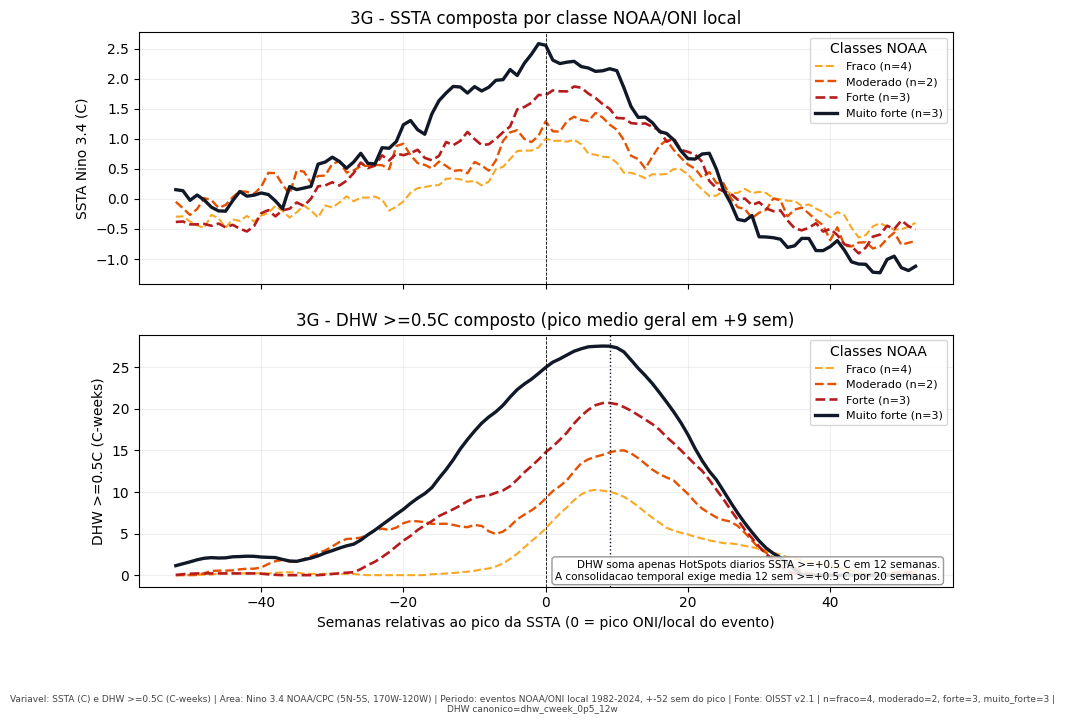

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_noaa(); ssta,dhw=w['nino34_ssta'],w['dhw_cweek_0p5_12w']; lags=list(range(-52,53))
groups=u.elnino_mean_groups(ev)

def comp(series,events):
    mm=[]
    for _,e in events.iterrows():
        i=series.index.get_indexer([e.peak_time],method='nearest')[0]
        seg=series.iloc[max(0,i-52):i+53]
        rel=((seg.index-series.index[i]).days/7).round().astype(int)
        mm.append(pd.Series(seg.values,index=rel).reindex(lags))
    return pd.DataFrame(mm).mean() if mm else pd.Series(index=lags,dtype=float)

comps={}; records=[]
for grupo,gg in groups.items():
    comps[grupo]=pd.DataFrame({'ssta':comp(ssta,gg),'dhw_cweek_0p5_12w':comp(dhw,gg)})
    for lag,row in comps[grupo].iterrows():
        records.append({'grupo':grupo,'rotulo':u.elnino_group_label(grupo,short=True),'n_eventos':len(gg),'semana_rel_pico':int(lag),'ssta':row['ssta'],'dhw_cweek_0p5_12w':row['dhw_cweek_0p5_12w']})
cp_long=pd.DataFrame(records)
u.save_table(cp_long,'phase3G_composto_ssta_dhw_classes_noaa.csv',index=False)
cp=pd.DataFrame({'ssta':comp(ssta,ev),'dhw_cweek_0p5_12w':comp(dhw,ev)}); u.save_table(cp.rename_axis('semana_rel_pico'),'phase3G_composto_ssta_dhw.csv')
lag_rows=[]
for grupo in u.ELNINO_MEAN_GROUP_ORDER:
    if len(groups[grupo]) == 0: continue
    lagpk=int(comps[grupo]['dhw_cweek_0p5_12w'].idxmax())
    lag_rows.append({'grupo':grupo,'rotulo':u.elnino_group_label(grupo,short=True),'n_eventos':len(groups[grupo]),'lag_pico_dhw_sem':lagpk,'dhw_pico_max_c_weeks':round(float(comps[grupo]['dhw_cweek_0p5_12w'].max()),2)})
lag_tab=pd.DataFrame(lag_rows); u.save_table(lag_tab,'phase3G_pico_dhw_por_classe.csv',index=False)
lagpk_all=int(cp['dhw_cweek_0p5_12w'].idxmax())
print('Pico composto do DHW C-week >=0.5C por classe NOAA:')
print(lag_tab.to_string(index=False))
fig,axes=plt.subplots(2,1,figsize=(10.5,7.2),sharex=True)
for grupo in u.ELNINO_MEAN_GROUP_ORDER:
    if len(groups[grupo]) == 0: continue
    meta=u.elnino_group_style(grupo); label=f"{meta['rotulo_curto']} (n={len(groups[grupo])})"
    axes[0].plot(comps[grupo].index,comps[grupo]['ssta'],color=meta['color'],lw=meta['linewidth'],ls=meta['linestyle'],label=label)
    axes[1].plot(comps[grupo].index,comps[grupo]['dhw_cweek_0p5_12w'],color=meta['color'],lw=meta['linewidth'],ls=meta['linestyle'],label=label)
for ax in axes:
    ax.axvline(0,color='k',ls='--',lw=.6); ax.grid(alpha=.2); ax.legend(fontsize=8,title='Classes NOAA')
axes[1].axvline(lagpk_all,color='#111827',ls=':',lw=1)
axes[0].set_ylabel('SSTA Nino 3.4 (C)'); axes[1].set_ylabel('DHW >=0.5C (C-weeks)')
axes[1].set_xlabel('Semanas relativas ao pico da SSTA (0 = pico ONI/local do evento)')
axes[0].set_title('3G - SSTA composta por classe NOAA/ONI local')
axes[1].set_title(f'3G - DHW >=0.5C composto (pico medio geral em {lagpk_all:+d} sem)')
u.add_note(axes[1], 'DHW soma apenas HotSpots diarios SSTA >=+0.5 C em 12 semanas.\nA consolidacao temporal exige media 12 sem >=+0.5 C por 20 semanas.', loc='lower right')
counts=ev['classe_noaa'].value_counts().to_dict()
u.stamp_caption(fig,variavel='SSTA (C) e DHW >=0.5C (C-weeks)',area=u.CAIXAS['nino34'],periodo='eventos NOAA/ONI local 1982-2024, +-52 sem do pico',fonte='OISST v2.1',n=', '.join(f"{k}={counts.get(k,0)}" for k in u.ELNINO_MEAN_GROUP_ORDER),extra='DHW canonico=dhw_cweek_0p5_12w')
u.save_fig(fig,'phase3G_composto_ssta_dhw.png'); plt.show()


In [2]:
rows=[]
for _,e in ev.iterrows():
    onset,peak,end=e.event_start,e.peak_time,e.event_end; meio=onset+(peak-onset)/2; seg=dhw.loc[onset:end]
    ipk=seg.idxmax() if seg.notna().any() else pd.NaT
    rows.append({'event_id':e.event_id,'classe':e.classe_noaa,'oni_pico_c':round(e.peak_oni_local_c if 'peak_oni_local_c' in e else e.peak_ssta_c,3),'ssta_mensal_pico_c':round(e.peak_monthly_ssta_c,3),'duracao_estacoes_oni':e.duration_oni_seasons if 'duration_oni_seasons' in e else e.duration_months,
     'dhw_nascimento':round(float(dhw.asof(onset)),2),'dhw_meio_cresc':round(float(dhw.asof(meio)),2),'dhw_no_pico_ssta':round(float(dhw.asof(peak)),2),
     'dhw_maximo':round(float(seg.max()),2) if seg.notna().any() else np.nan,'defasagem_pico_dhw_sem':int(round((ipk-peak).days/7)) if pd.notna(ipk) else np.nan,'dhw_fim':round(float(dhw.asof(end)),2)})
met=pd.DataFrame(rows); u.save_table(met,'phase3G_eventos_dhw.csv',index=False); met


[tabela] data\processed\parquet\statistics\phase3G_eventos_dhw.csv


,event_id,classe,oni_pico_c,ssta_mensal_pico_c,duracao_estacoes_oni,dhw_nascimento,dhw_meio_cresc,dhw_no_pico_ssta,dhw_maximo,defasagem_pico_dhw_sem,dhw_fim
0,el_nino_oisst_1982_1983,muito_forte,2.120,2.213,11,3.59,8.03,22.47,26.19,6,15.19
1,el_nino_oisst_1986_1988,moderado,1.211,1.223,16,1.15,10.79,6.86,14.81,11,10.27
2,el_nino_oisst_1991_1992,forte,1.625,1.736,10,4.72,4.80,11.60,19.81,9,12.51
3,el_nino_oisst_1994_1995,fraco,0.968,1.192,5,0.58,2.72,5.40,11.94,7,11.79
4,el_nino_oisst_1997_1998,muito_forte,2.146,2.166,11,0.83,15.69,24.28,25.80,10,20.67
5,el_nino_oisst_2002_2003,moderado,1.213,1.250,8,2.14,6.37,9.93,15.18,10,14.66
6,el_nino_oisst_2004,fraco,0.652,0.681,5,1.52,2.88,3.69,7.13,6,6.78
7,el_nino_oisst_2006_2007,fraco,0.920,1.128,5,0.21,2.57,6.91,10.69,4,10.69
8,el_nino_oisst_2009_2010,forte,1.586,1.719,10,0.89,7.25,12.23,19.47,8,16.15
9,el_nino_oisst_2014_2016,muito_forte,2.592,2.448,19,0.00,6.57,27.50,31.09,9,26.54


[tabela] data\processed\parquet\statistics\phase3G_escalonamento.csv


[figura] data\processed\figures\fase3\phase3G_escalonamento.png


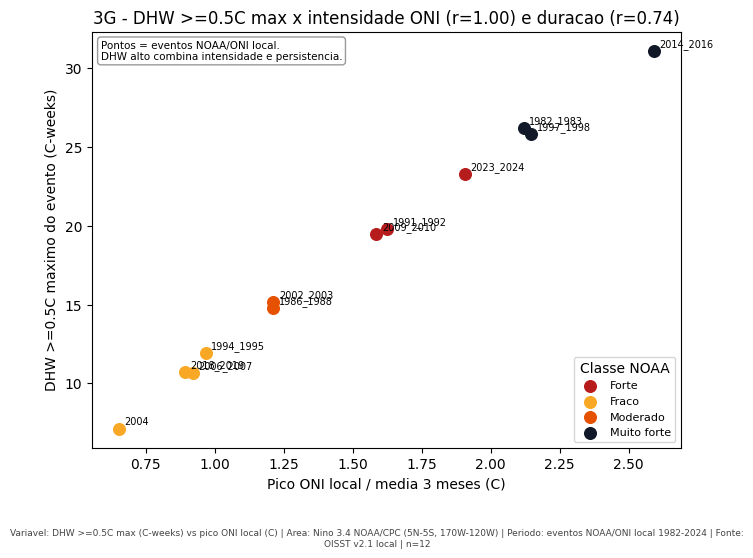

In [3]:
mm=met.dropna(subset=['dhw_maximo'])
ri=float(np.corrcoef(mm['dhw_maximo'],mm['oni_pico_c'])[0,1]); rd=float(np.corrcoef(mm['dhw_maximo'],mm['duracao_estacoes_oni'])[0,1])
u.save_table(pd.DataFrame([{'metrica_dhw':'dhw_cweek_0p5_12w','relacao':'dhw_max x oni_pico','r':round(ri,3),'n':len(mm)},{'metrica_dhw':'dhw_cweek_0p5_12w','relacao':'dhw_max x duracao_oni','r':round(rd,3),'n':len(mm)}]),'phase3G_escalonamento.csv',index=False)
fig,ax=plt.subplots(figsize=(7.6,5.4))
for cls,g in mm.groupby('classe'):
    meta=u.elnino_group_style(cls); ax.scatter(g['oni_pico_c'],g['dhw_maximo'],label=meta['rotulo_curto'],color=meta['color'],s=70)
for _,r in mm.iterrows(): ax.annotate(r['event_id'].replace('el_nino_oisst_',''),(r['oni_pico_c'],r['dhw_maximo']),fontsize=7,xytext=(4,3),textcoords='offset points')
ax.set_xlabel('Pico ONI local / media 3 meses (C)'); ax.set_ylabel('DHW >=0.5C maximo do evento (C-weeks)'); ax.legend(fontsize=8,title='Classe NOAA')
ax.set_title(f'3G - DHW >=0.5C max x intensidade ONI (r={ri:.2f}) e duracao (r={rd:.2f})')
u.add_note(ax, 'Pontos = eventos NOAA/ONI local.\nDHW alto combina intensidade e persistencia.', loc='upper left')
u.stamp_caption(fig,variavel='DHW >=0.5C max (C-weeks) vs pico ONI local (C)',area=u.CAIXAS['nino34'],periodo='eventos NOAA/ONI local 1982-2024',fonte='OISST v2.1 local',n=str(len(mm)))
u.save_fig(fig,'phase3G_escalonamento.png'); plt.show()


[tabela] data\processed\parquet\statistics\phase3G_estado_atual.csv


[figura] data\processed\figures\fase3\phase3G_mapa_dhw_lon.png


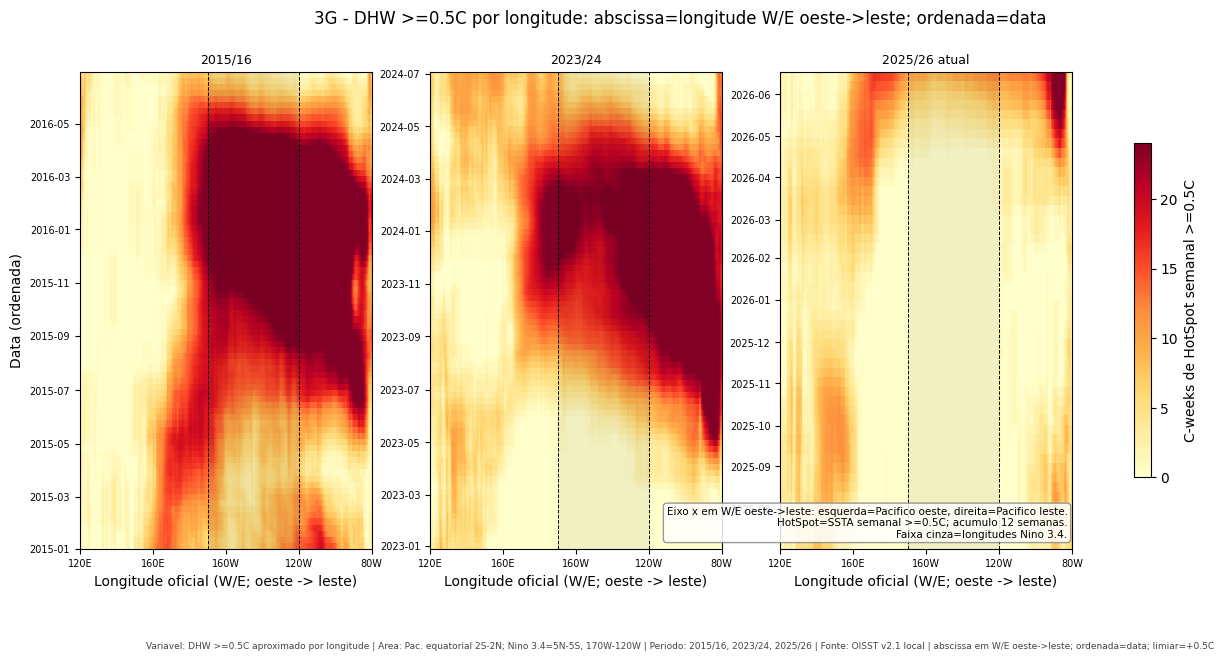

DHW >=0.5C lon max atual (jun/2026): 31.34


In [4]:
eq=u.load_eqband_weekly()
hot=eq.where(eq>=0.5,0.0)
dl=hot.rolling(12,min_periods=12).sum()
wins=[('2015-01-04','2016-06-26','2015/16'),('2023-01-01','2024-06-30','2023/24'),('2025-07-01',None,'2025/26 atual')]
fig,axes=plt.subplots(1,3,figsize=(16,6.2)); lon=eq.columns.values
for ax,(t0,t1,tt) in zip(axes,wins):
    seg=dl.loc[t0:t1] if t1 else dl.loc[t0:]; pc=ax.pcolormesh(lon,seg.index,seg.values,cmap='YlOrRd',vmin=0,vmax=24,shading='auto')
    u.add_nino34_lon_band(ax,label=False); u.format_lon_axis(ax, xlabel='Longitude oficial (W/E; oeste -> leste)')
    ax.set_title(tt,fontsize=9); ax.tick_params(labelsize=7)
axes[0].set_ylabel('Data (ordenada)')
fig.suptitle('3G - DHW >=0.5C por longitude: abscissa=longitude W/E oeste->leste; ordenada=data')
fig.colorbar(pc,ax=axes,label='C-weeks de HotSpot semanal >=0.5C',shrink=.7)
u.add_note(axes[-1], 'Eixo x em W/E oeste->leste: esquerda=Pacifico oeste, direita=Pacifico leste.\nHotSpot=SSTA semanal >=0.5C; acumulo 12 semanas.\nFaixa cinza=longitudes Nino 3.4.', loc='lower right')
u.stamp_caption(fig,variavel='DHW >=0.5C aproximado por longitude',area='Pac. equatorial 2S-2N; Nino 3.4=5N-5S, 170W-120W',periodo='2015/16, 2023/24, 2025/26',fonte='OISST v2.1 local',extra='abscissa em W/E oeste->leste; ordenada=data; limiar=+0.5C')
at=dl.loc['2026-06-01':].max().max(); u.save_table(pd.DataFrame([{'dhw_ge_0p5_lon_max_atual_cweeks':round(float(at),2)}]),'phase3G_estado_atual.csv',index=False)
u.save_fig(fig,'phase3G_mapa_dhw_lon.png'); plt.show(); print('DHW >=0.5C lon max atual (jun/2026):',round(float(at),2))


**Leitura do 3G.** O DHW e **integrador**: pica depois do pico da SSTA, logo nao e precursor longo. A leitura agora segue as classes NOAA/ONI local (`fraco`, `moderado`, `forte`, `muito_forte`). O DHW canonico soma apenas HotSpots diarios >=+0.5 C em janela de 12 semanas e escala com intensidade/duracao, funcionando como severidade acumulada/memoria curta.
